In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [6]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label     = NTC
pert_key      = pert
treatment_key = treatment


ntc_label     = non-targeting
pert_key      = pert
treatment_key = treatment


'NTC'

In [9]:
data = slk.datasets.replogle()

'''Alternatively for your own data:
data = sc.read_h5ad(PATH_TO_YOUR_DATA)
slk_prepare_data(data, pert_key=PERT_KEY, ntc_label=NTC_LABEL, treatment_key=TREATMENT_KEY|None, inplace=True)
'''

'Alternatively for your own data:\ndata = sc.read_h5ad(PATH_TO_YOUR_DATA)\nslk_prepare_data(data, pert_key=PERT_KEY, ntc_label=NTC_LABEL, treatment_key=TREATMENT_KEY|None, inplace=True)\n'

In [8]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
sum([len(pathways[i]) for i in range(len(pathways))])
print("Pathways:", len(pathways))

overlap = any(len(set(pathways[i]) & set(pathways[j])) > 0 for i in range(len(pathways)) for j in range(i + 1, len(pathways)))
print("Overlap exists between pathways:" if overlap else "No overlap between pathways.")

Perturbations: 682
Pathways: 8
No overlap between pathways.


In [9]:
slk.pp.treat_effect(
    data,
    label_col = 'gene',
    control_label = 'non-targeting',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 681/681 [00:03<00:00, 226.16it/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, batch_size=4096, shuffle=True, num_workers=9, device=device)

In [ ]:
slk.tl.save_results(results, '../data/replogle_model.pth')

In [ ]:
model = slk.tl.load_results('../data/replogle_model.pth')

In [181]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [169]:
data.uns['results']

{'acc': 0.29397037625312805,
 'rho_corr': array([[ 9.9999988e-01, -1.1308072e-01,  1.5144584e-01, ...,
          6.4577550e-02,  1.3242310e-01,  1.7049361e-04],
        [-1.1308072e-01,  1.0000000e+00,  3.7654316e-01, ...,
          3.5604635e-01,  1.4782131e-01,  3.4043312e-01],
        [ 1.5144584e-01,  3.7654316e-01,  1.0000000e+00, ...,
          4.2534378e-01,  4.0075219e-01,  2.1419856e-01],
        ...,
        [ 6.4577550e-02,  3.5604635e-01,  4.2534378e-01, ...,
          1.0000000e+00, -3.3118073e-02,  8.9385802e-01],
        [ 1.3242310e-01,  1.4782131e-01,  4.0075219e-01, ...,
         -3.3118073e-02,  1.0000000e+00, -2.4552172e-01],
        [ 1.7049361e-04,  3.4043312e-01,  2.1419856e-01, ...,
          8.9385802e-01, -2.4552172e-01,  1.0000001e+00]], dtype=float32),
 'z_corr': array([[ 1.        , -0.14270999,  0.3535124 , ...,  0.90199304,
          0.04801017,  0.9509593 ],
        [-0.14270999,  1.        , -0.0883888 , ..., -0.1058675 ,
          0.13520926, -0.117523

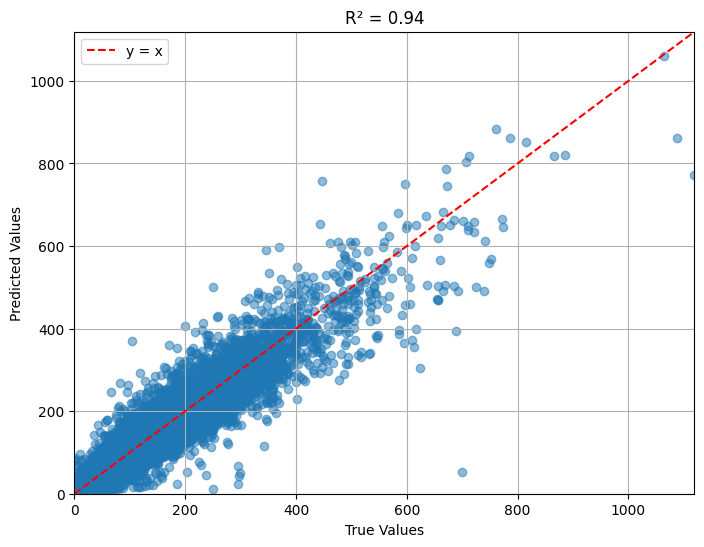

In [143]:
slk.pl.plot_r2(data)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


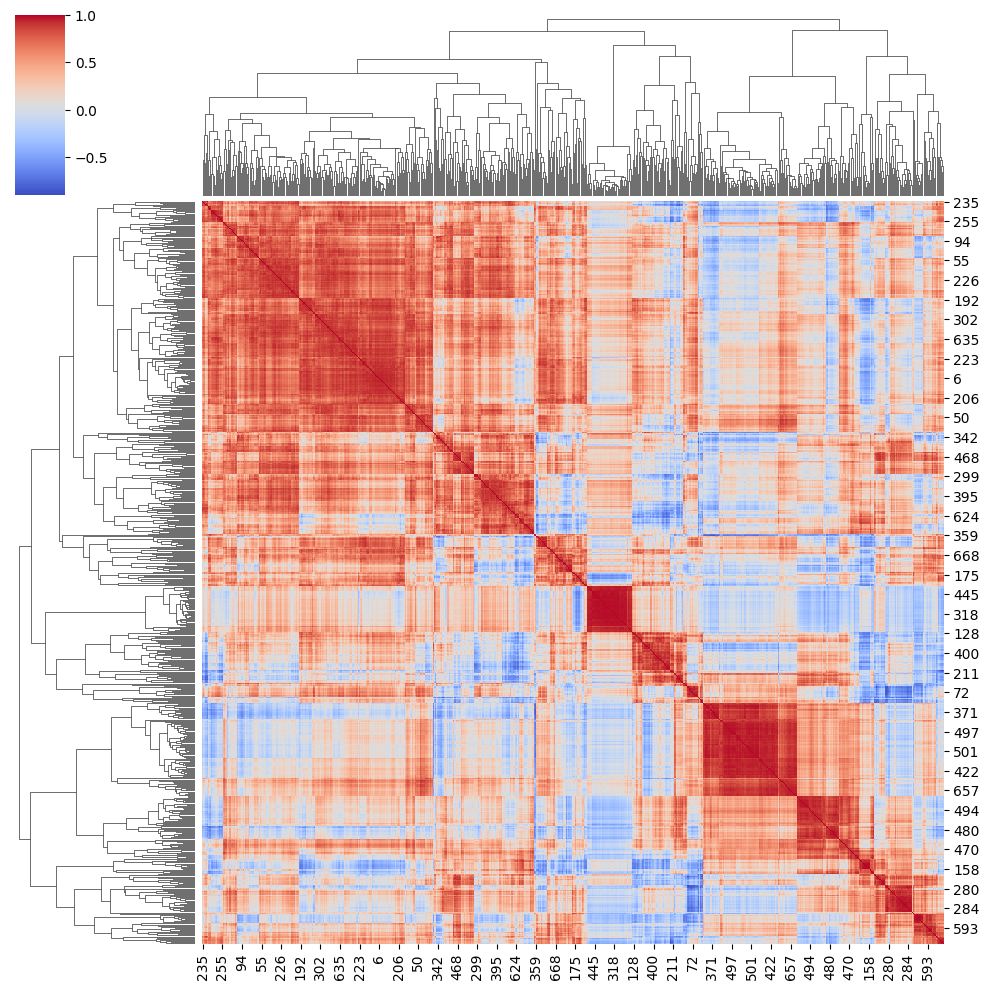

In [149]:
slk.pl.plot_corr(data)

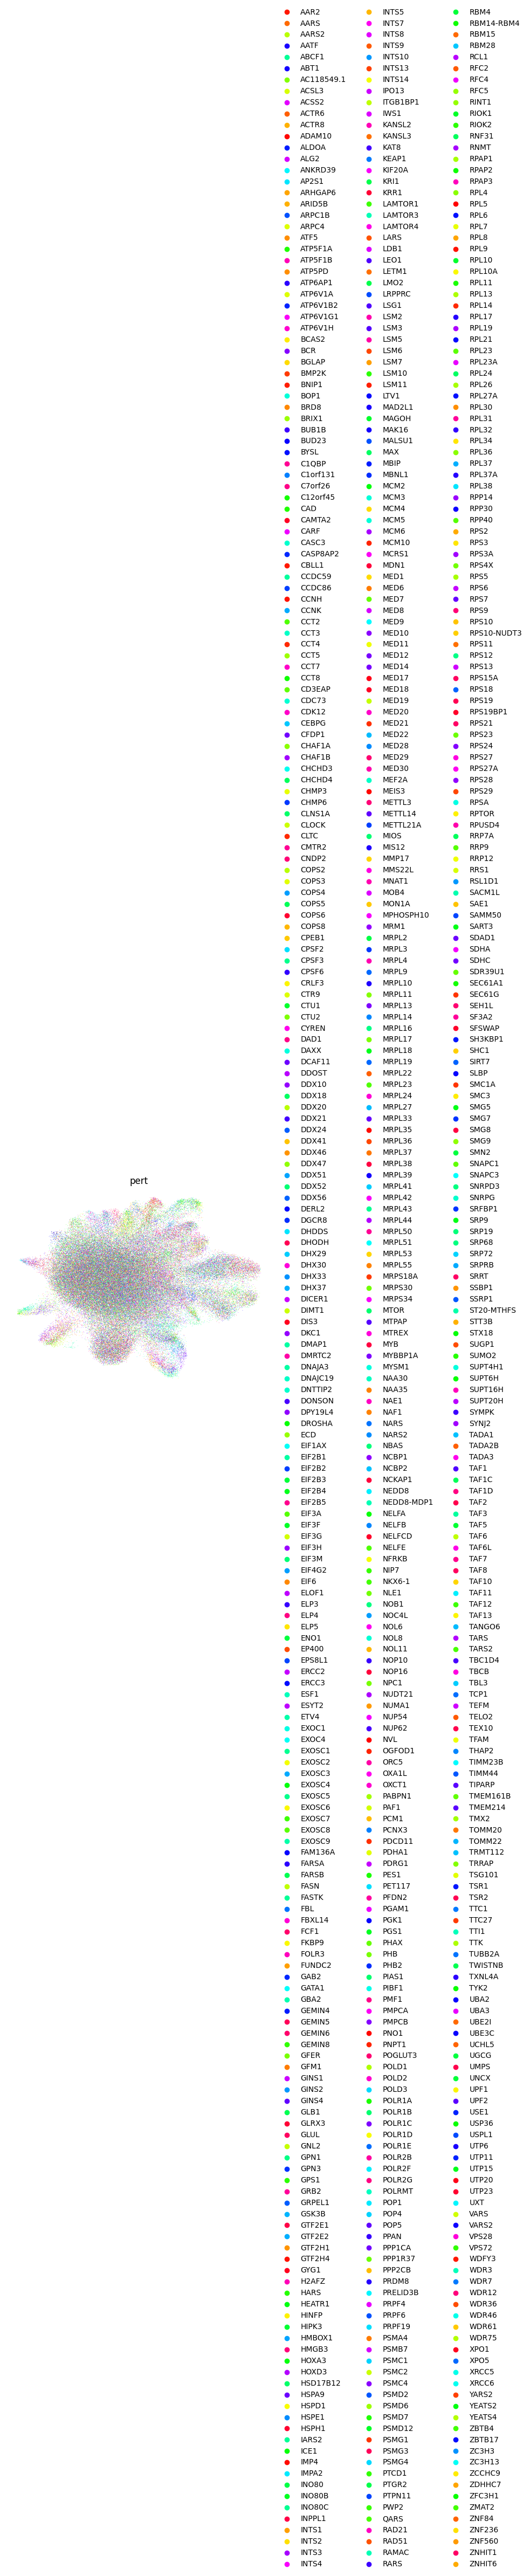

In [152]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [175]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.772  (p = 0.0e+00)
 Pearson  r = 0.785  (p = 0.0e+00)


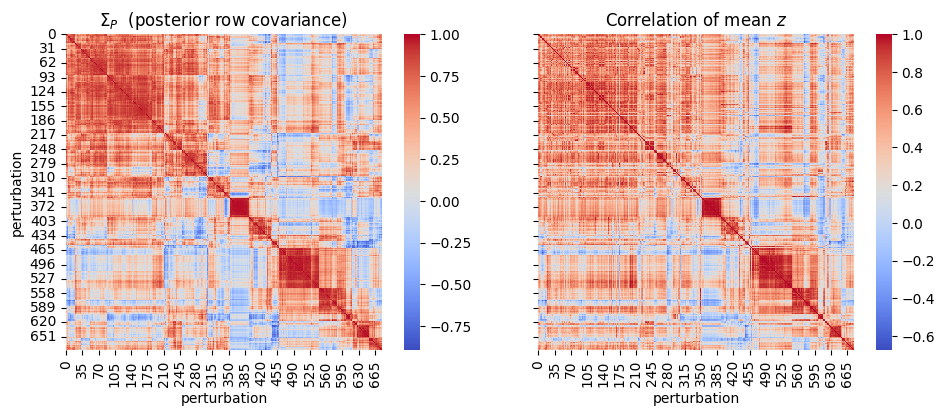

In [179]:
slk.pl.plot_zcorr(data)

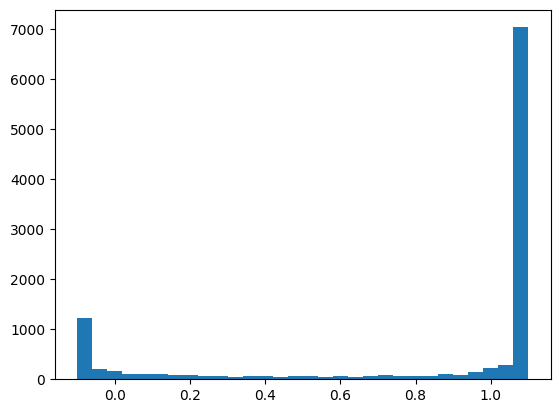

In [ ]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

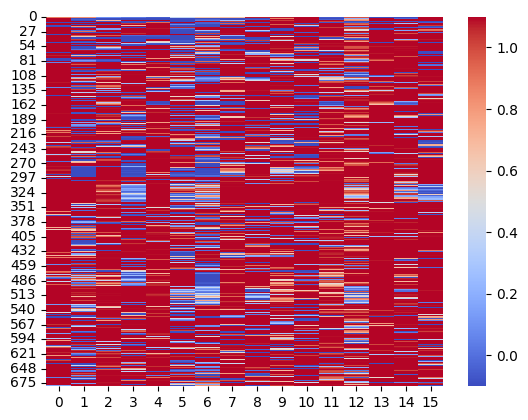

In [184]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [192]:
C = data.uns['results']['rho_corr']

#Specific subsetting for replogle. Otherwise just use C directly
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]
dataset = slk.tl.PerturbMatchingDataset(data)
gene_ids = [dataset.perturbation_dict[g] for g in all_genes]
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

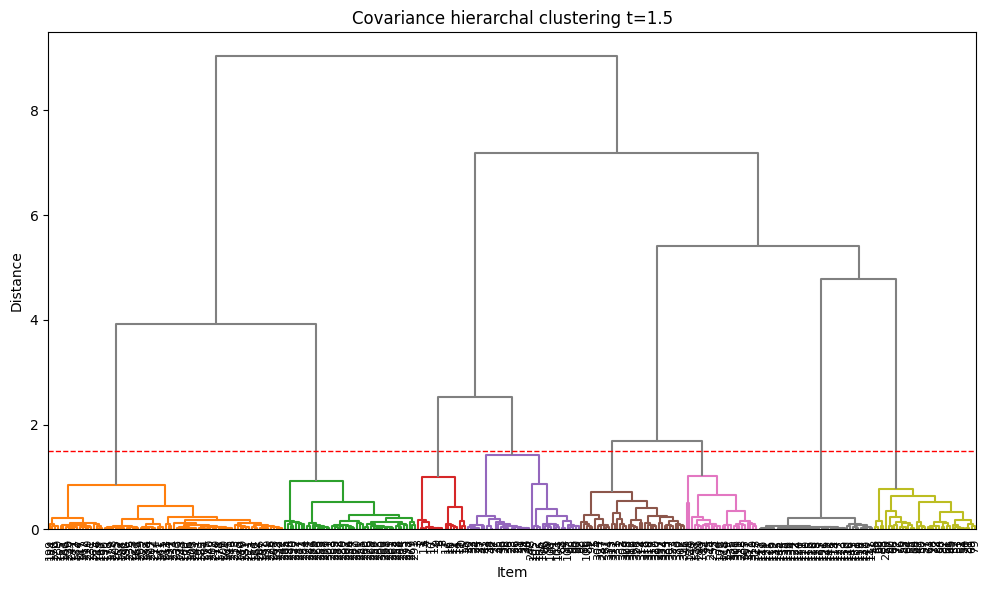

In [194]:
groups = slk.tl.cluster_rho(data, t=1.5, rho_corr=cov_subset, show=True)

In [210]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
ZC3H3,3
ZFC3H1,3
CAMTA2,5
DHX29,3
DIS3,3
...,...
SNRPG,5
TIPARP,5
TTC27,5
TXNL4A,5


## From here on out it is validation of replogle

In [195]:
from collections import Counter

# Flatten all genes from all pathways
#all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

# Count how many times each gene appears
gene_counts = Counter(all_genes)

# Find genes that appear in more than one pathway
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]

if shared_genes:
    print(f"⚠️ {len(shared_genes)} genes are shared across pathways:")
    print(shared_genes[:20])  # show first 20 for inspection
else:
    print("✅ Each gene appears in exactly one pathway.")


#pert df
pathway_genes = np.concatenate([i for i in list(data.uns['pathways'].values())])
pathway_genes = pathway_genes[pathway_genes != 'LSM5']
print(len(pathway_genes))
print(len(all_genes))
perts = pd.DataFrame(groups, index=all_genes, columns=['cluster'])
perts = perts.loc[pathway_genes]

#pathway df
gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes if gene != 'LSM5'
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient="index", columns=["cluster"])


perts = perts.drop(shared_genes, errors="ignore")
pathway_df = pathway_df.drop(shared_genes, errors="ignore")

print("After removal:")
print("perts size     :", perts.shape)
print("pathway_df size:", pathway_df.shape)

✅ Each gene appears in exactly one pathway.
335
335
After removal:
perts size     : (335, 1)
pathway_df size: (335, 1)


In [196]:
from sklearn.metrics import adjusted_rand_score

# Align on the same gene index
perts_aligned = perts.loc[pathway_df.index]

# Compute ARI
ari = adjusted_rand_score(pathway_df["cluster"], perts_aligned["cluster"])
print("ARI =", ari)

ARI = 0.7978545602361145


In [197]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']
pathway_df

,pathway,gene
ZC3H3,EXOSOME,ZC3H3
ZFC3H1,EXOSOME,ZFC3H1
CAMTA2,EXOSOME,CAMTA2
DHX29,EXOSOME,DHX29
DIS3,EXOSOME,DIS3
...,...,...
SNRPG,SPLICEOSOME,SNRPG
TIPARP,SPLICEOSOME,TIPARP
TTC27,SPLICEOSOME,TTC27
TXNL4A,SPLICEOSOME,TXNL4A


In [198]:
perts_aligned['gene'] = perts_aligned.index.copy()
perts_aligned

,cluster,gene
ZC3H3,3,ZC3H3
ZFC3H1,3,ZFC3H1
CAMTA2,5,CAMTA2
DHX29,3,DHX29
DIS3,3,DIS3
...,...,...
SNRPG,5,SNRPG
TIPARP,5,TIPARP
TTC27,5,TTC27
TXNL4A,5,TXNL4A


In [199]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False


def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
):
    # 1) Merge on gene
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col,
        how="inner",
        validate="one_to_one"
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    # Optional: filter tiny pathways to stabilize Hungarian/enrichment
    if min_pathway_size > 1:
        keep_path = df[pathway_col].value_counts()
        keep_path = keep_path[keep_path >= min_pathway_size].index
        df = df[df[pathway_col].isin(keep_path)].copy()

    # Cast to string for safe indexing
    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # 2) Contingency (rows=pathways, cols=clusters)
    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    # 3) Hungarian alignment to maximize correct assignments (sum of diagonal)
    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)  # maximize
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # 4) Remap clusters → pathways and compute metrics
    mapped = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy = float(is_match.mean())

    # Label-based external clustering metrics (label strings are fine)
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)

    # 5) Per-cluster purity & mapped target
    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        purity = (g[pathway_col] == majority).mean()
        purity_rows.append({
            "cluster": str(cl),
            "size": len(g),
            "mapped_pathway": mapping.get(str(cl), None),
            "purity": purity
        })
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    # 6) Normalized contingency for plotting
    contingency = contingency_df.copy()
    contingency_row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    contingency_col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    # 7) Pathway↔cluster enrichment (hypergeometric with FDR)
    #    N = total genes, K = pathway size, n = cluster size, k = overlap
    N = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            # p-value: probability of ≥k overlap by chance
            pval = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K, "n": n, "N": N, "pval": float(pval)})

    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        # Bonferroni fallback
        m = max(len(enrich_df), 1)
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * m, 1.0)

    # Signed/visual score: -log10(q)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    # 8) Attach mapped labels into the merged table
    df["mapped_pathway"] = mapped
    df["is_match"] = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}
        ),
        "mapping": mapping,
        "accuracy": accuracy,
        "ari": ari,
        "ami": ami,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": contingency_row_norm,
        "contingency_col_norm": contingency_col_norm,
        "enrichment": enrich_df,
    }


In [200]:
results = align_and_summarize(
    clusters_df=perts_aligned,          # gene↦cluster from covariance HC
    pathways_df=pathway_df,             # gene↦pathway ground truth
    gene_col="gene",
    cluster_col="cluster",
    pathway_col="pathway",
    min_pathway_size=1,                 # optional: filter tiny pathways
)

print("Best cluster→pathway mapping:")
for cl, pw in results["mapping"].items():
    print(f"  {cl} → {pw}")

print(f"\nGlobal alignment accuracy: {results['accuracy']:.3f}")
print(f"ARI: {results['ari']:.3f} | AMI: {results['ami']:.3f}\n")

print("Per-cluster purity:")
print(results["purity_df"])

Best cluster→pathway mapping:
  3 → EXOSOME
  4 → MEDIATOR_COMPLEX
  8 → MT_PROTEIN_TRANSLOCATION
  6 → NUCLEOTIDE_EXCISION_REPAIR
  7 → S39_RIBOSOMAL_UNIT
  1 → S40_RIBOSOMAL_UNIT
  2 → S60_RIBOSOMAL_UNIT
  5 → SPLICEOSOME

Global alignment accuracy: 0.830
ARI: 0.798 | AMI: 0.802

Per-cluster purity:
         size              mapped_pathway    purity
cluster                                            
1          85          S40_RIBOSOMAL_UNIT  1.000000
2          48          S60_RIBOSOMAL_UNIT  1.000000
3          18                     EXOSOME  1.000000
4          41            MEDIATOR_COMPLEX  0.560976
5          38                 SPLICEOSOME  0.684211
6          26  NUCLEOTIDE_EXCISION_REPAIR  0.384615
7          42          S39_RIBOSOMAL_UNIT  1.000000
8          37    MT_PROTEIN_TRANSLOCATION  0.972973


/var/tmp/ipykernel_1330979/3854716668.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works


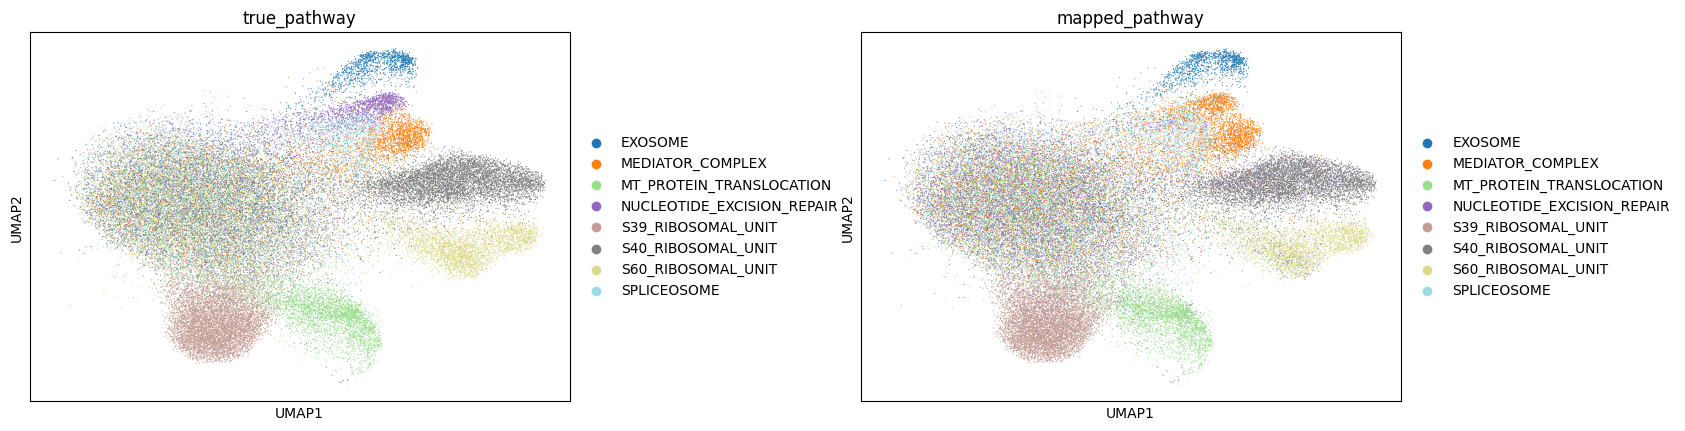

In [201]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt

# --- your existing setup ---
results_df = results['merged']
clustered_genes = results_df["gene"].unique()

z_sub = sub[sub.obs["pert"].isin(clustered_genes)].copy()

gene_to_true   = dict(zip(results_df["gene"], results_df["pathway"]))
gene_to_mapped = dict(zip(results_df["gene"], results_df["mapped_pathway"]))

z_sub.obs["true_pathway"]   = z_sub.obs["pert"].map(gene_to_true)
z_sub.obs["mapped_pathway"] = z_sub.obs["pert"].map(gene_to_mapped)

# Drop NA mapped rows
z_sub = z_sub[z_sub.obs["mapped_pathway"].notna() & (z_sub.obs["mapped_pathway"] != "NA")].copy()

# --- NEW: enforce identical palettes for both columns ---
# 1) Make both columns categorical with the SAME category set & order
true_vals   = pd.Index(z_sub.obs["true_pathway"].dropna().unique().astype(str))
mapped_vals = pd.Index(z_sub.obs["mapped_pathway"].dropna().unique().astype(str))
all_cats = pd.Index(np.unique(true_vals.union(mapped_vals)))  # sorted union

cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs["true_pathway"]   = z_sub.obs["true_pathway"].astype("string").astype(cat_dtype)
z_sub.obs["mapped_pathway"] = z_sub.obs["mapped_pathway"].astype("string").astype(cat_dtype)

# 2) Build a single color palette over all categories
cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}

# 3) Write per-column color lists in each column's category order
true_order   = list(z_sub.obs["true_pathway"].cat.categories)
mapped_order = list(z_sub.obs["mapped_pathway"].cat.categories)

z_sub.uns["true_pathway_colors"]   = [shared_palette[c] for c in true_order]
z_sub.uns["mapped_pathway_colors"] = [shared_palette[c] for c in mapped_order]

# --- Plot (colors now matched across panels) ---
import scanpy as sc
sc.pl.umap(
    z_sub,
    color=["true_pathway", "mapped_pathway"],
    wspace=0.4,
)